<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 17 - Ejemplo 1 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

In [83]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

from Parcial2.Parcial2_20231085 import random_state


Se dispone de un conjunto de datos con 768 registros correspondientes a pacientes mujeres de 21 años o más, con información médica relacionada con el diagnóstico de diabetes.

El objetivo es construir un modelo de clasificación mediante árbol de decisión que permita predecir si una paciente presenta o no diabetes a partir de diferentes variables clínicas.

La variable objetivo es Outcome, donde generalmente:

- 0: No presenta diabetes.
- 1: Presenta diabetes.

Las variables predictoras del modelo son:

| Variable | Descripción |
|---|---|
| **Pregnancies** | Número de embarazos. |
| **Glucose** | Concentración de glucosa en sangre. |
| **BloodPressure** | Presión arterial. |
| **SkinThickness** | Grosor del pliegue cutáneo. |
| **Insulin** | Nivel de insulina. |
| **BMI** | Índice de masa corporal. |
| **DiabetesPedigreeFunction** | Indicador asociado a antecedentes familiares de diabetes. |
| **Age** | Edad de la paciente. |

A partir de estas variables, el árbol de decisión buscará identificar patrones que permitan clasificar correctamente a las pacientes según su condición diabética o no diabética. Para ello, el modelo dividirá los datos en diferentes ramas utilizando reglas de decisión basadas en los valores de las variables predictoras, con el fin de obtener grupos cada vez más homogéneos respecto a la variable Outcome.

a) Realizar un análisis gráfico de los datos.

b) Particionar el conjunto en un 25% para la validación y el resto de entrenamiento.

c) Crear un árbol de decisión con los parámetros por defecto.

d) Crear un árbol de decisión con una profundidad máxima de 3.

e) Implmentar un árbol de decisión con número máximo de nodos hojas de 10.

f) Realizar la validación cruzada para determinar el valor de la profundidad máxima que optimice el accuracy score

g) Crear un nuevo modelo con el resultado anterior y usarlo para clasificar a una mujer con la media de las variables independientes.

In [84]:
#Realizar el análisis de los datos

datos = pd.read_csv("diabetes2.csv")

In [86]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [87]:
X_independientes = datos.drop(["Outcome"], axis=1)

y_dependiente = datos["Outcome"]

In [88]:
X_independientes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


<Figure size 640x480 with 0 Axes>

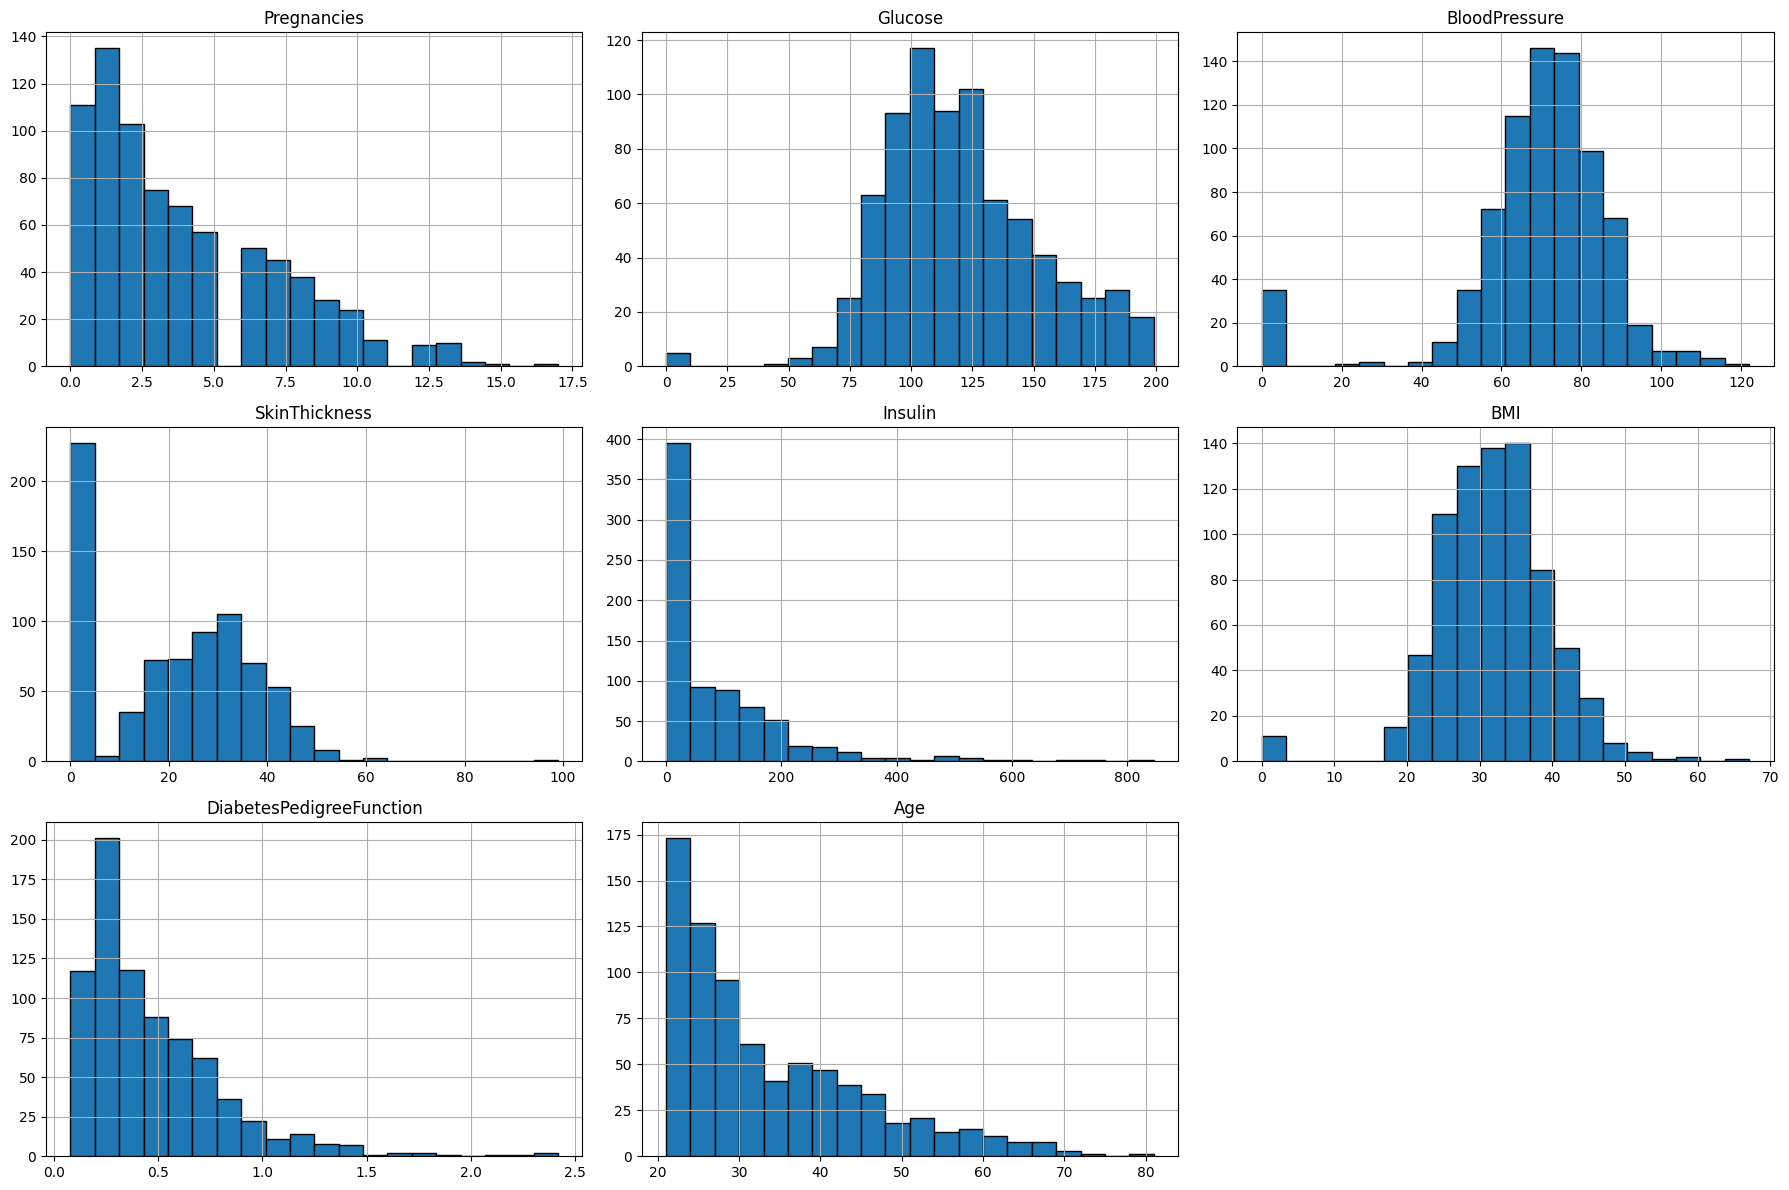

In [89]:
plt.figure()
X_independientes.hist(figsize=(18,12),  bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

In [90]:
#Realizar la partición de los datos

from sklearn.model_selection import train_test_split

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_independientes,y_dependiente, test_size=0.25, random_state=2026)

In [91]:
from sklearn.tree import DecisionTreeClassifier

#Crear el objeto de clase árbol con los parámetros por defecto
tree_clf = DecisionTreeClassifier(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train);

[Text(0.5562193627450981, 0.9642857142857143, 'x[1] <= 143.5\ngini = 0.457\nsamples = 576\nvalue = [372, 204]'),
 Text(0.19332107843137256, 0.8928571428571429, 'x[5] <= 27.35\ngini = 0.37\nsamples = 449\nvalue = [339, 110]'),
 Text(0.37477022058823534, 0.9285714285714286, 'True  '),
 Text(0.04411764705882353, 0.8214285714285714, 'x[5] <= 9.1\ngini = 0.073\nsamples = 131\nvalue = [126, 5]'),
 Text(0.0196078431372549, 0.75, 'x[1] <= 114.5\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.00980392156862745, 0.6785714285714286, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.029411764705882353, 0.6785714285714286, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.06862745098039216, 0.75, 'x[5] <= 26.35\ngini = 0.048\nsamples = 122\nvalue = [119, 3]'),
 Text(0.049019607843137254, 0.6785714285714286, 'x[7] <= 59.0\ngini = 0.019\nsamples = 106\nvalue = [105, 1]'),
 Text(0.0392156862745098, 0.6071428571428571, 'gini = 0.0\nsamples = 102\nvalue = [102, 0]'),
 Text(0.058823529411764705

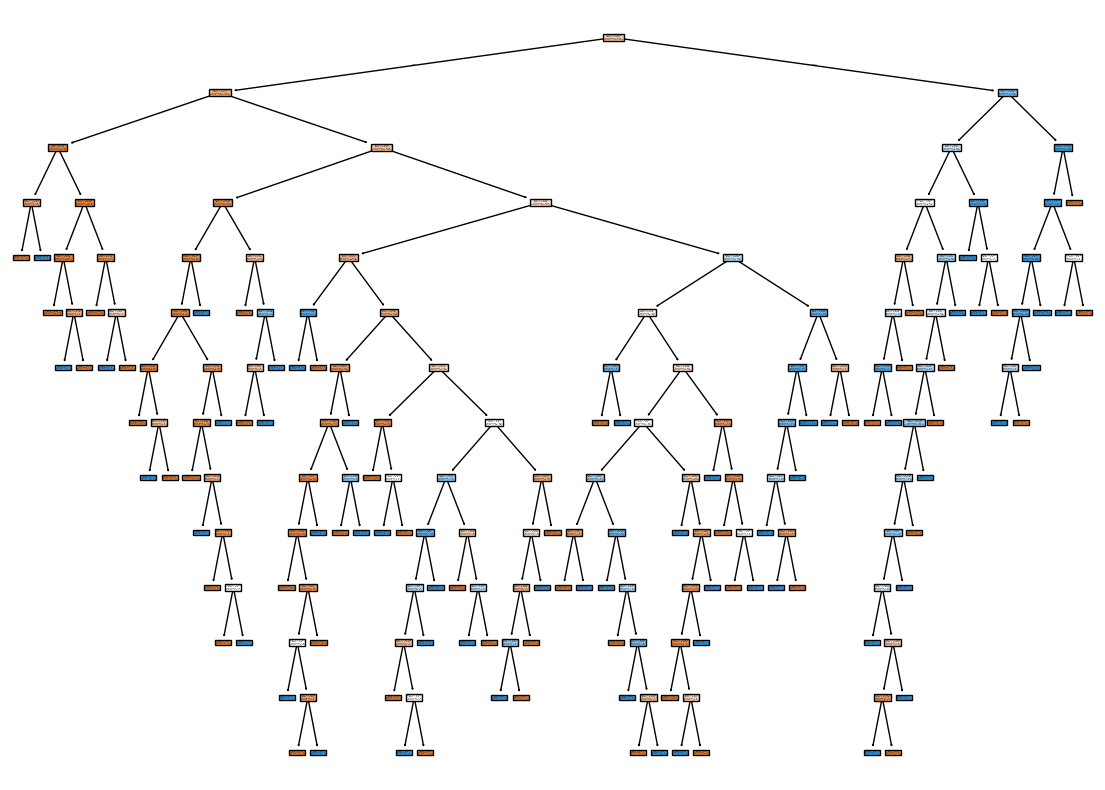

In [92]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf,filled=True)

In [93]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 0.65625


Text(50.722222222222214, 0.5, 'Real')

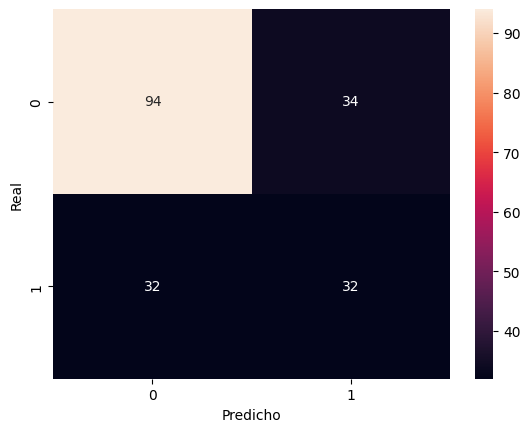

In [94]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [95]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y_test, y_pred_a)
recall_1 = recall_score(y_test, y_pred_a)
f1_1 = f1_score(y_test, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1,f1_1]})
metricas

,Métricas,Valores
0,Precisión,0.484848
1,Recall,0.500000
2,F1,0.492308


El árbol de decisión con parámetros por defecto presenta un desempeño general moderado, con un accuracy de 65.63 %. Sin embargo, al analizar la clase de mayor interés, correspondiente a las pacientes con diabetes, se observa que tanto la precisión como el recall son bajos. El modelo solo identifica correctamente al 50 % de las pacientes diabéticas y, además, cuando predice diabetes, acierta en menos de la mitad de los casos. Por tanto, este modelo no resulta suficientemente confiable para la identificación de pacientes con diabetes y requiere ajustes en sus hiperparámetros, como la profundidad máxima o el número máximo de nodos hoja.

In [96]:
#Crear el objeto de clase árbol usando una profundidad máxima de 3
tree_clf_b = DecisionTreeClassifier(max_depth=3 ,random_state = 2026)
#Ajustar el arbol
tree_clf_b.fit(X_train, y_train);

[Text(0.5, 0.875, 'x[1] <= 143.5\ngini = 0.457\nsamples = 576\nvalue = [372, 204]'),
 Text(0.25, 0.625, 'x[5] <= 27.35\ngini = 0.37\nsamples = 449\nvalue = [339, 110]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[5] <= 9.1\ngini = 0.073\nsamples = 131\nvalue = [126, 5]'),
 Text(0.0625, 0.125, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.1875, 0.125, 'gini = 0.048\nsamples = 122\nvalue = [119, 3]'),
 Text(0.375, 0.375, 'x[1] <= 99.5\ngini = 0.442\nsamples = 318\nvalue = [213, 105]'),
 Text(0.3125, 0.125, 'gini = 0.192\nsamples = 93\nvalue = [83, 10]'),
 Text(0.4375, 0.125, 'gini = 0.488\nsamples = 225\nvalue = [130, 95]'),
 Text(0.75, 0.625, 'x[1] <= 166.5\ngini = 0.385\nsamples = 127\nvalue = [33, 94]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= 85.5\ngini = 0.487\nsamples = 69\nvalue = [29, 40]'),
 Text(0.5625, 0.125, 'gini = 0.5\nsamples = 57\nvalue = [28, 29]'),
 Text(0.6875, 0.125, 'gini = 0.153\nsamples = 12\nvalue = [1, 11]'),
 Text(0.875, 0.3

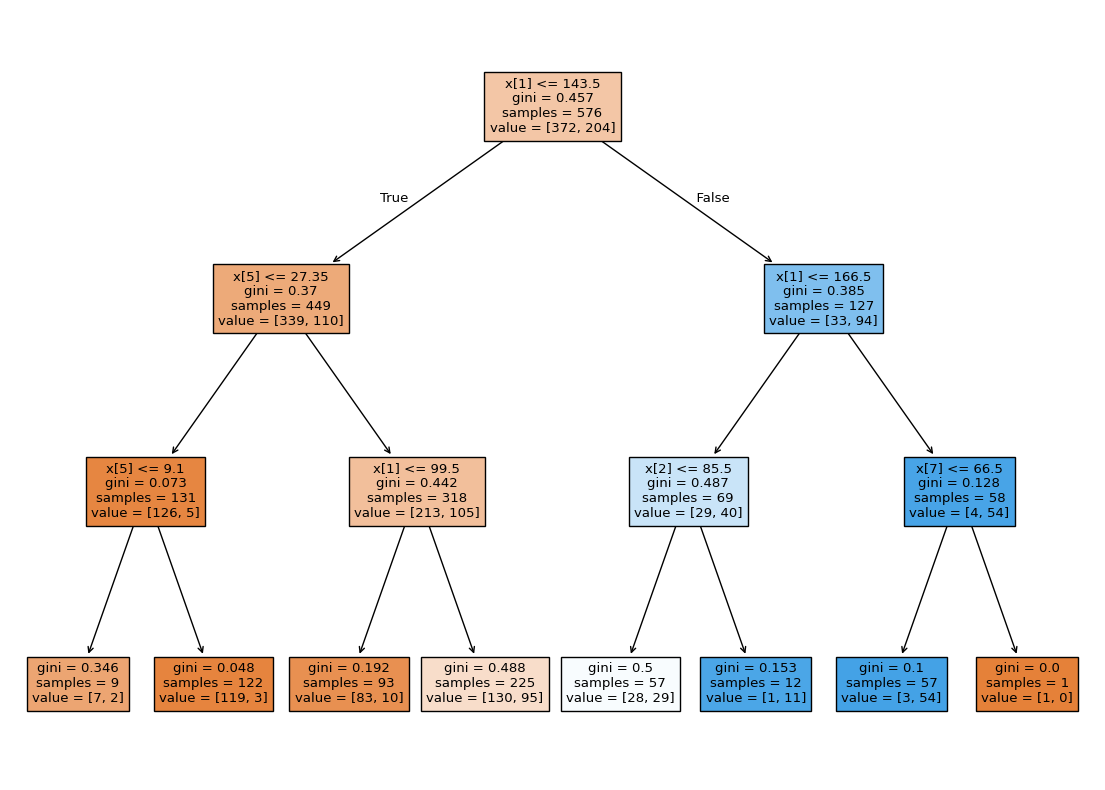

In [97]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_b,filled=True)

In [98]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_b = tree_clf_b.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)


El accuracy score que se tiene es 0.7447916666666666


Text(50.722222222222214, 0.5, 'Real')

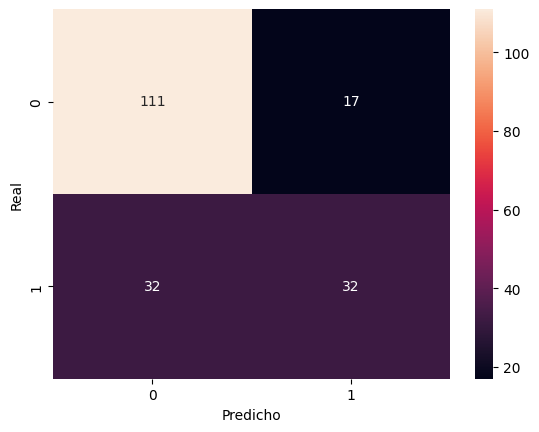

In [99]:
from sklearn.metrics import confusion_matrix
#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")


In [100]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_2 = precision_score(y_test, y_pred_b)
recall_2 = recall_score(y_test, y_pred_b)
f1_2= f1_score(y_test, y_pred_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_2, recall_2,f1_2]})
metricas

,Métricas,Valores
0,Precisión,0.653061
1,Recall,0.500000
2,F1,0.566372


El árbol de decisión con max_depth=3 presenta un mejor desempeño general que el árbol con parámetros por defecto. El accuracy aumentó de 65.63 % a 74.48 %, y la precisión para la clase positiva mejoró de 48.48 % a 65.31 %. Sin embargo, el recall se mantuvo en 50 %, lo que significa que el modelo todavía no logra identificar adecuadamente a todas las pacientes diabéticas. Por tanto, aunque este modelo es más estable y preciso que el árbol inicial, aún presenta limitaciones para detectar casos positivos de diabetes.

In [126]:
from sklearn.tree import DecisionTreeClassifier
#Crear el objeto de clase árbol usando una profundidad máxima de 10
tree_clf_c = DecisionTreeClassifier(max_leaf_nodes=10 ,random_state = 2026)
#Ajustar el arbol
tree_clf_c.fit(X_train, y_train);

[Text(0.5, 0.9166666666666666, 'x[1] <= 143.5\ngini = 0.457\nsamples = 576\nvalue = [372, 204]'),
 Text(0.15384615384615385, 0.75, 'x[5] <= 27.35\ngini = 0.37\nsamples = 449\nvalue = [339, 110]'),
 Text(0.3269230769230769, 0.8333333333333333, 'True  '),
 Text(0.07692307692307693, 0.5833333333333334, 'gini = 0.073\nsamples = 131\nvalue = [126, 5]'),
 Text(0.23076923076923078, 0.5833333333333334, 'x[1] <= 99.5\ngini = 0.442\nsamples = 318\nvalue = [213, 105]'),
 Text(0.15384615384615385, 0.4166666666666667, 'gini = 0.192\nsamples = 93\nvalue = [83, 10]'),
 Text(0.3076923076923077, 0.4166666666666667, 'x[7] <= 30.5\ngini = 0.488\nsamples = 225\nvalue = [130, 95]'),
 Text(0.15384615384615385, 0.25, 'x[2] <= 22.0\ngini = 0.407\nsamples = 123\nvalue = [88, 35]'),
 Text(0.07692307692307693, 0.08333333333333333, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.23076923076923078, 0.08333333333333333, 'gini = 0.375\nsamples = 116\nvalue = [87, 29]'),
 Text(0.46153846153846156, 0.25, 'x[6] <

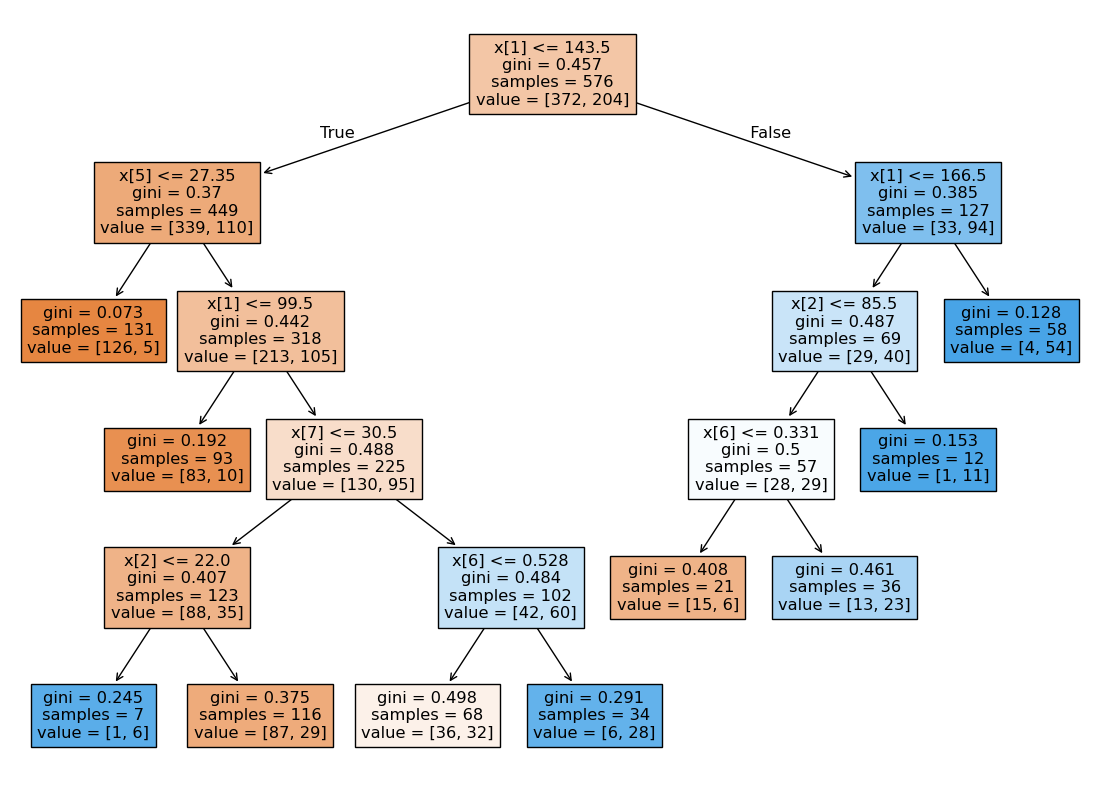

In [127]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_c,filled=True)

In [128]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_c = tree_clf_c.predict(X_test)
accuracy_c = accuracy_score(y_test, y_pred_c)
print("El accuracy score que se tiene es %s" %accuracy_c)

El accuracy score que se tiene es 0.7552083333333334


Text(50.722222222222214, 0.5, 'Real')

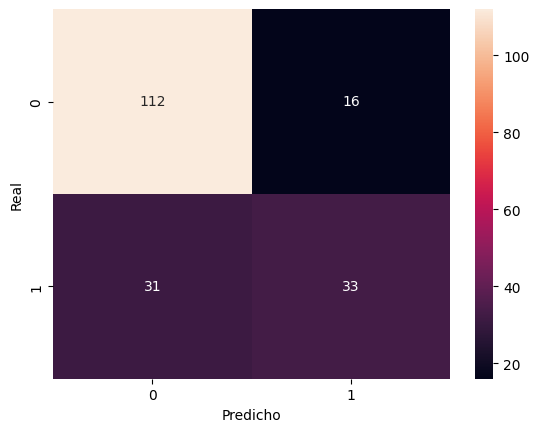

In [129]:
from sklearn.metrics import confusion_matrix
#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [130]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_c = precision_score(y_test, y_pred_c)
recall_c = recall_score(y_test, y_pred_c)
f1_c= f1_score(y_test, y_pred_c)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_c, recall_c,f1_c]})
metricas

,Métricas,Valores
0,Precisión,0.673469
1,Recall,0.515625
2,F1,0.584071


El modelo con max_leaf_nodes=10 presenta el mejor desempeño entre los tres modelos evaluados. Obtiene el mayor accuracy, la mayor precisión, el mayor recall y el mayor F1-score para la clase positiva. Esto indica que controlar el número máximo de nodos hoja permitió construir un árbol más eficiente y con mejor capacidad de generalización. No obstante, aunque el modelo mejora respecto a los anteriores, el recall de la clase 1 sigue siendo moderado, por lo que todavía no identifica correctamente a todas las pacientes con diabetes.

In [118]:
#Realizar la validación cruzada

from sklearn import tree
from sklearn.model_selection import cross_val_score

k_range = range(3,20)
depth = list()
for i in k_range:
    clf = tree.DecisionTreeClassifier(max_depth=i, random_state= 2026)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10, n_jobs=4)
    depth.append(scores.mean())
print(depth)

[np.float64(0.7186630369026012), np.float64(0.7359649122807017), np.float64(0.7361161524500908), np.float64(0.7013611615245009), np.float64(0.7100725952813068), np.float64(0.7239866908650937), np.float64(0.7222928009679371), np.float64(0.7170901391409558), np.float64(0.7188142770719902), np.float64(0.7066243194192378), np.float64(0.7205384150030248), np.float64(0.717059891107078), np.float64(0.7153357531760436), np.float64(0.7135813672111313), np.float64(0.7135813672111313), np.float64(0.7135813672111313), np.float64(0.7135813672111313)]


In [121]:
np.max(depth)

np.float64(0.7361161524500908)

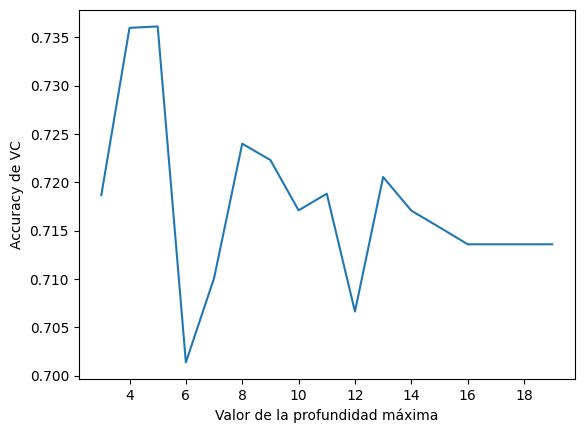

In [119]:
#Representar la validación cruzada
plt.plot(k_range, depth)
plt.xlabel('Valor de la profundidad máxima')
plt.ylabel('Accuracy de VC')
plt.show()

In [120]:
print("El valor de K que maximiza la accuracy es", np.argmax(scores) + 3)

El valor de K que maximiza la accuracy es 8


In [109]:
#Implementar con el mejor de la profundidad máxima

In [122]:
from sklearn.tree import DecisionTreeClassifier
#Crear el objeto de clase árbol usando una profundidad máxima de 10
tree_clf_d = DecisionTreeClassifier(max_depth=5 ,random_state = 2026)
#Ajustar el arbol
tree_clf_d.fit(X_train, y_train);

In [124]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_d = tree_clf_d.predict(X_test)
accuracy_d = accuracy_score(y_test, y_pred_d)
print("El accuracy score que se tiene es %s" %accuracy_d)

El accuracy score que se tiene es 0.734375


In [131]:
#Mejor árbol de todos es tree_clf_c
#Obtener la media para clasificar
X_media = np.mean(X_train, axis=0)
#Realizar la clasificación
media_clf = tree_clf_c.predict(X_media.values.reshape(1,-1))
print("La paciente se clasifica como %s"%media_clf)

La paciente se clasifica como [0]


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
